In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

In [2]:
class Standard_CNN(nn.Module):
    def __init__(self):#modified vgg16+lenet5
        super().__init__()
        self.Conv1 = nn.Conv2d(1,6,kernel_size=3,stride=1,padding=1)#maxpooling doesnt change the cin or cout.. only downsample the picture
        self.Conv2 = nn.Conv2d(6,16,kernel_size=3,stride=1,padding=1)
        self.fc1    = nn.Linear(16*8*8,120)
        self.fc2    = nn.Linear(120,84)
        self.fc3    = nn.Linear(84,10)
    def forward(self,x):
        x = torch.relu(self.Conv1(x))
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = torch.relu(self.Conv2(x))
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = x.view(-1,16*8*8)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [3]:
transform = transforms.Compose(
    [transforms.Pad(padding=2),transforms.ToTensor()] #make the 28x28 fashionmnist picture 32x32
)

In [4]:
batch_size = 50
data_root = "../FashionMNIST"
trainset = torchvision.datasets.FashionMNIST(root=data_root,train=True,download=True,transform=transform)
testset = torchvision.datasets.FashionMNIST(root=data_root,train=False,download=True,transform=transform)
trainloader = torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)
testloader = torch.utils.data.DataLoader(testset,batch_size=batch_size, shuffle=False)
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
model = Standard_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(model.parameters(),lr=0.001)
optimizer2 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0)
optimizer3 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


Using device: mps


In [5]:
def accuracy(loader):
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        for data,labels in loader:
            data, labels = data.to(device), labels.to(device)
            output = model(data)
            _,predicted = torch.max(output.data,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct /total

In [6]:
epochs = 10
adam_batch_losses = []
adam_train_losses = []
adam_train_accuracies = []
adam_test_accuracies = []
adam_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    adam_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    adam_train_accuracies.append(train_acc)
    adam_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
adam_end = time.time()
adam_time = adam_end - adam_start
print("time for training", adam_time, "seconds")

Epoch 1/10 | Loss: 0.5852 | Train Acc: 86.03% | Test Acc: 85.11%
Epoch 2/10 | Loss: 0.3630 | Train Acc: 87.53% | Test Acc: 86.59%
Epoch 3/10 | Loss: 0.3114 | Train Acc: 89.67% | Test Acc: 88.35%
Epoch 4/10 | Loss: 0.2810 | Train Acc: 90.39% | Test Acc: 89.19%
Epoch 5/10 | Loss: 0.2561 | Train Acc: 91.45% | Test Acc: 89.87%
Epoch 6/10 | Loss: 0.2386 | Train Acc: 91.75% | Test Acc: 90.09%
Epoch 7/10 | Loss: 0.2229 | Train Acc: 92.50% | Test Acc: 90.26%
Epoch 8/10 | Loss: 0.2088 | Train Acc: 92.35% | Test Acc: 90.33%
Epoch 9/10 | Loss: 0.1975 | Train Acc: 93.39% | Test Acc: 90.74%
Epoch 10/10 | Loss: 0.1872 | Train Acc: 93.31% | Test Acc: 90.53%
time for training 183.94118213653564 seconds


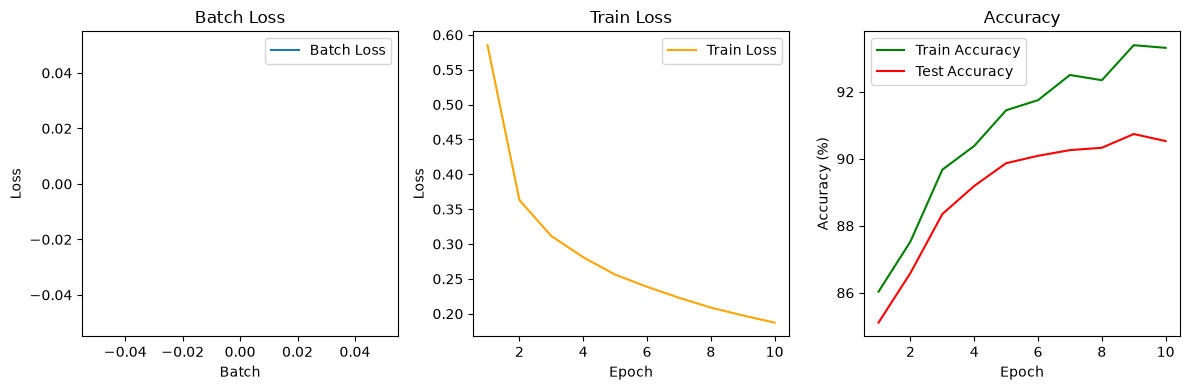

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(adam_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), adam_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), adam_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), adam_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
epochs = 10
sgd_batch_losses = []
sgd_train_losses = []
sgd_train_accuracies = []
sgd_test_accuracies = []
sgd_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    sgd_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    sgd_train_accuracies.append(train_acc)
    sgd_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
sgd_end = time.time()
sgd_time = sgd_end - sgd_start
print("time for training", sgd_time, "seconds")

Epoch 1/10 | Loss: 0.1586 | Train Acc: 94.21% | Test Acc: 91.43%
Epoch 2/10 | Loss: 0.1538 | Train Acc: 94.37% | Test Acc: 91.47%
Epoch 3/10 | Loss: 0.1517 | Train Acc: 94.33% | Test Acc: 91.45%
Epoch 4/10 | Loss: 0.1504 | Train Acc: 94.46% | Test Acc: 91.40%
Epoch 5/10 | Loss: 0.1495 | Train Acc: 94.39% | Test Acc: 91.39%
Epoch 6/10 | Loss: 0.1486 | Train Acc: 94.54% | Test Acc: 91.62%
Epoch 7/10 | Loss: 0.1479 | Train Acc: 94.53% | Test Acc: 91.57%
Epoch 8/10 | Loss: 0.1472 | Train Acc: 94.57% | Test Acc: 91.65%
Epoch 9/10 | Loss: 0.1467 | Train Acc: 94.61% | Test Acc: 91.60%
Epoch 10/10 | Loss: 0.1462 | Train Acc: 94.61% | Test Acc: 91.56%
time for training 198.46192407608032 seconds


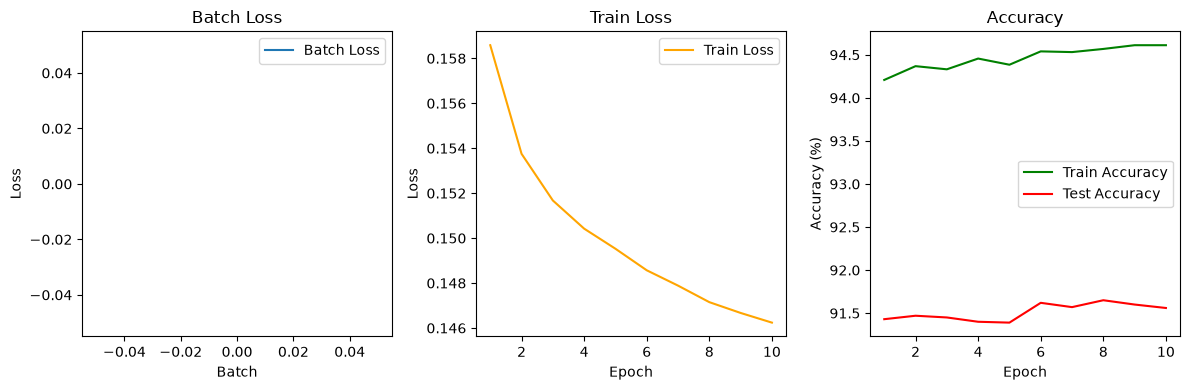

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(sgd_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), sgd_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), sgd_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), sgd_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
epochs = 10
sgd_m_batch_losses = []
sgd_m_train_losses = []
sgd_m_train_accuracies = []
sgd_m_test_accuracies = []
sgd_m_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer3.zero_grad()
        loss.backward()
        optimizer3.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    sgd_m_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    sgd_m_train_accuracies.append(train_acc)
    sgd_m_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
sgd_m_end = time.time()
sgd_m_time = sgd_m_end - sgd_m_start
print("time for training", sgd_m_time, "seconds")

Epoch 1/10 | Loss: 0.1526 | Train Acc: 94.49% | Test Acc: 91.48%
Epoch 2/10 | Loss: 0.1511 | Train Acc: 94.23% | Test Acc: 91.11%
Epoch 3/10 | Loss: 0.1475 | Train Acc: 94.59% | Test Acc: 91.29%
Epoch 4/10 | Loss: 0.1455 | Train Acc: 94.44% | Test Acc: 91.10%
Epoch 5/10 | Loss: 0.1441 | Train Acc: 94.99% | Test Acc: 91.34%
Epoch 6/10 | Loss: 0.1423 | Train Acc: 94.87% | Test Acc: 91.48%
Epoch 7/10 | Loss: 0.1410 | Train Acc: 94.81% | Test Acc: 91.32%
Epoch 8/10 | Loss: 0.1397 | Train Acc: 95.03% | Test Acc: 91.42%
Epoch 9/10 | Loss: 0.1388 | Train Acc: 95.05% | Test Acc: 91.56%
Epoch 10/10 | Loss: 0.1379 | Train Acc: 95.17% | Test Acc: 91.57%
time for training 188.10820603370667 seconds


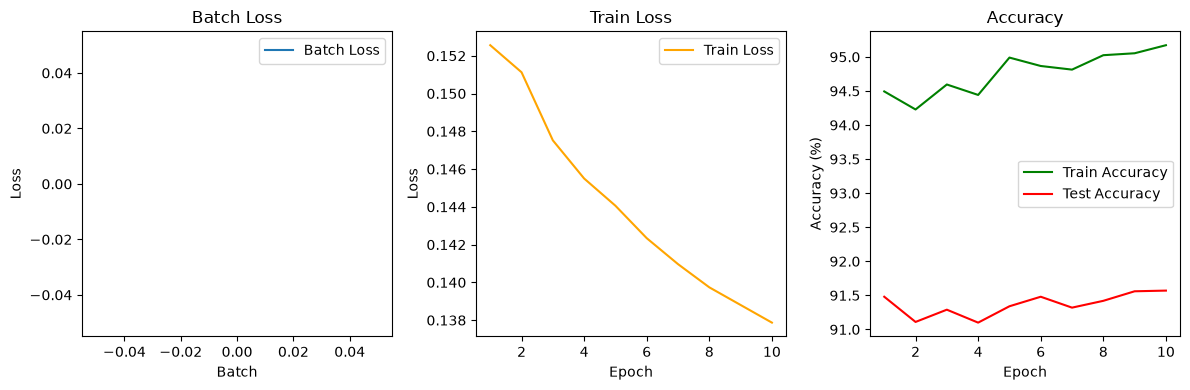

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(sgd_m_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), sgd_m_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), sgd_m_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), sgd_m_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
class DepthWise_Separable_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1_depth = nn.Conv2d(1,6,kernel_size=3,groups=1)
        self.conv1_point = nn.Conv2d(kernel_size=1,groups=1)
        self.conv2_depth = nn.Conv2d(6,16,kernel_size=3,groups=1)
        self.conv3_point = nn.Conv2d(kernel_size=1,groups=1)